In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mikoajfish99/lions-or-cheetahs-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lions-or-cheetahs-image-classification' dataset.
Path to dataset files: /kaggle/input/lions-or-cheetahs-image-classification


In [ ]:
ls /root/.cache/kagglehub/datasets/mikoajfish99/lions-or-cheetahs-image-classification/versions/1

images/


In [ ]:
mv "/root/.cache/kagglehub/datasets/mikoajfish99/lions-or-cheetahs-image-classification/versions/1/images" /content

mv: cannot move '/root/.cache/kagglehub/datasets/mikoajfish99/lions-or-cheetahs-image-classification/versions/1/images' to '/content/images': Directory not empty


In [ ]:
cd /content/images

/content/images


In [ ]:
pwd

'/content/images'

In [ ]:
import tensorflow as tf
import os

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import cv2
import imghdr

In [ ]:
cd ..

/content


In [ ]:
data_dir = "images"

In [ ]:
image_exts = ['jpeg','jpg', 'bmp', 'png']


In [ ]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))
            os.remove(image_path)

In [ ]:
data = tf.keras.utils.image_dataset_from_directory('images')

Found 200 files belonging to 2 classes.


In [ ]:
data_iterator = data.as_numpy_iterator()

In [ ]:
batch = data_iterator.next()

In [ ]:
len(batch)

2

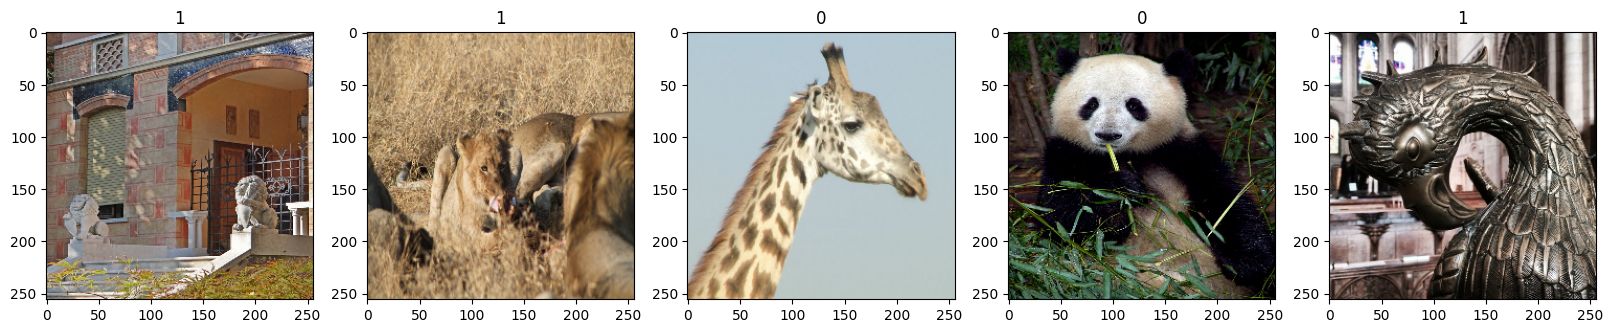

In [ ]:
fig, ax = plt.subplots(ncols=5, figsize=(20,20))
for idx, img in enumerate(batch[0][:5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [ ]:
print(data.class_names)

['Cheetahs', 'Lions']


In [ ]:
data = data.map(lambda x,y: (x/255, y))

In [ ]:
data.as_numpy_iterator().next()

(array([[[[0.09770986, 0.16633731, 0.18790594],
          [0.10393689, 0.16862746, 0.20458026],
          [0.10687041, 0.16569394, 0.21667433],
          ...,
          [0.0951057 , 0.11863511, 0.14282322],
          [0.08464307, 0.10817249, 0.1317019 ],
          [0.06862745, 0.0882353 , 0.1       ]],
 
         [[0.09612439, 0.15689339, 0.1804228 ],
          [0.0970818 , 0.16374847, 0.19904259],
          [0.10200674, 0.16277574, 0.21375613],
          ...,
          [0.10589767, 0.13529412, 0.16075368],
          [0.08134957, 0.10585172, 0.12058058],
          [0.06665135, 0.08625919, 0.08821998]],
 
         [[0.08627451, 0.14509805, 0.16862746],
          [0.08917739, 0.15780485, 0.19309896],
          [0.09803922, 0.16078432, 0.21176471],
          ...,
          [0.10815717, 0.13200061, 0.1500383 ],
          [0.08368566, 0.10133272, 0.11082261],
          [0.07450981, 0.09411765, 0.09607843]],
 
         ...,
 
         [[0.32431066, 0.30470282, 0.28180146],
          [0.31733

In [ ]:
train_size = int(len(data)*.7) #70% train
val_size = int(len(data)*.2) #20% validation
test_size = int(len(data)*.1)#10% test

In [ ]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [ ]:
from tensorflow.keras.models import Sequential #singl input and singl output
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras import regularizers


In [ ]:
model = Sequential()


In [ ]:
model.add(Conv2D(16,(3,3), strides=1,activation='relu',input_shape = (256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32,(3,3),strides=1,activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(256,activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
logdir = 'logs'

In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)


In [ ]:
hist = model.fit(train,epochs=17,validation_data=val,callbacks=tensorboard_callback)

Epoch 1/17
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 517ms/step - accuracy: 0.4922 - loss: 1.3867 - val_accuracy: 0.4375 - val_loss: 1.1196
Epoch 2/17
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step - accuracy: 0.5547 - loss: 1.0668 - val_accuracy: 0.5000 - val_loss: 1.0264
Epoch 3/17
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.6016 - loss: 1.0055 - val_accuracy: 0.7500 - val_loss: 0.9646
Epoch 4/17
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 0.5625 - loss: 0.9587 - val_accuracy: 0.4062 - val_loss: 0.9509
Epoch 5/17
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 469ms/step - accuracy: 0.4922 - loss: 0.9273 - val_accuracy: 0.5938 - val_loss: 0.8979
Epoch 6/17
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5781 - loss: 0.8988 - val_accuracy: 0.6250 - val_loss: 0.8738
Epoch 7/17
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 605ms/step - accuracy: 0.6172 - loss: 0.8675 - val_accuracy: 0.5625 - val_loss: 0.8563
Epoch 8/17
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.7578 - loss: 0.8384 - val_accuracy: 0.8438 - val_loss: 0.

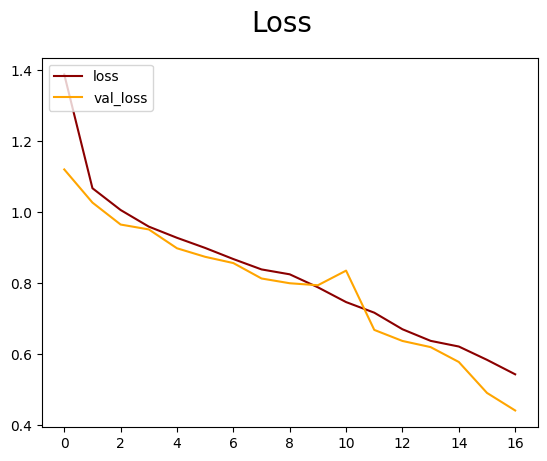

In [ ]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='darkred', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

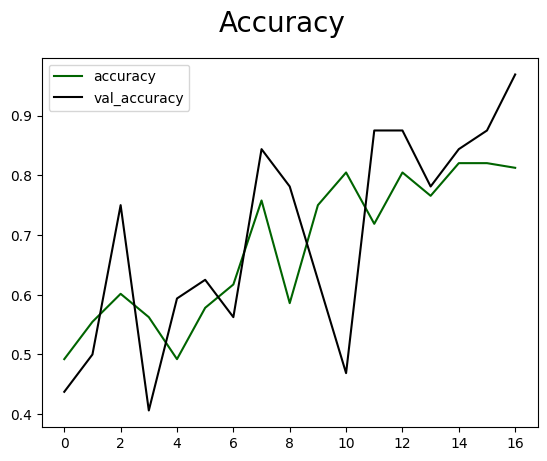

In [ ]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [ ]:
import cv2

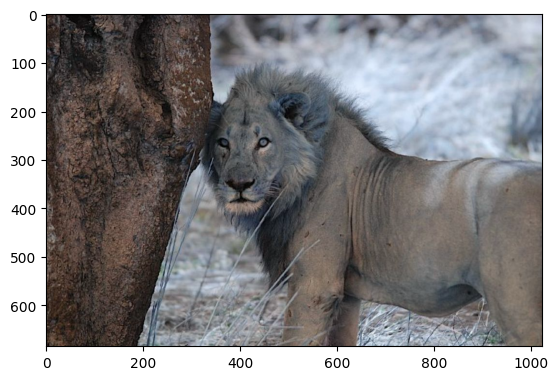

In [ ]:
img = cv2.imread('/content/images/Lions/0054521c7ff56e05.jpg')
plt.imshow(img)
plt.show()

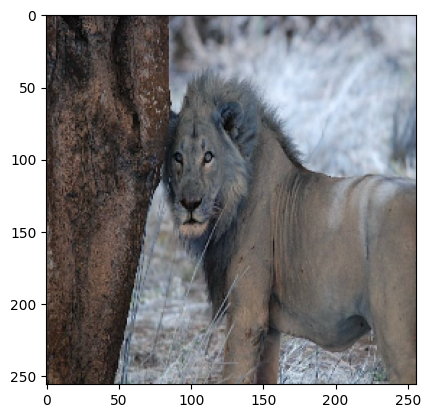

In [ ]:
img = cv2.resize(img,(256,256))
plt.imshow(img)
plt.show()

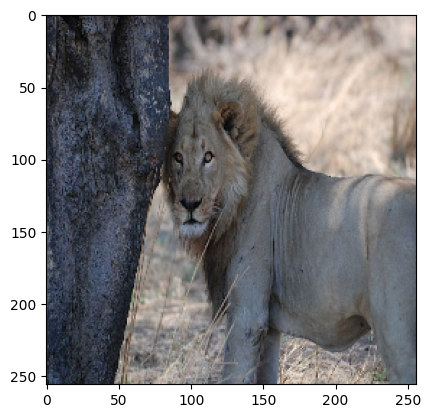

In [ ]:
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()


In [ ]:
yhat = model.predict(np.expand_dims(img/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [ ]:
yhat

array([[0.7891475]], dtype=float32)

In [ ]:
if yhat > 0.5:
    print(f'Predicted class is Lion')
else:
    print(f'Predicted class is Cheetah')

Predicted class is Lion


In [ ]:
model.save("lion_tiger.keras")

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
print(tf.keras.__version__)

3.13.2
